In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.linalg import eigh, cholesky
from scipy.stats import norm
import linearmodels.panel as lmp
from pylab import plot, show, axis, subplot, xlabel, ylabel, grid
import semopy
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from sklearn.decomposition import PCA
from IPython.display import Image
import graphviz
from stepmix.stepmix import StepMix


In [2]:
df=pd.read_csv('../../data/junaeb3.csv')
df.describe()

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
count,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,...,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,30051.000000,31055.000000,30682.000000,31055.000000,31055.000000
mean,0.538979,82.589084,1.017787,0.720335,0.966511,1.114088,1.391177,1.262856,1.256352,1.268588,...,1.333666,1.853743,1.385349,1.502785,1.694735,2.556620,0.911544,13.069291,12.955756,0.092803
std,0.498486,4.360270,1.370552,0.449415,0.189671,0.394004,0.650190,0.585766,0.578266,0.564929,...,0.666009,0.941171,0.668783,0.799375,0.984946,1.068041,0.283961,3.338320,3.425190,0.943509
min,0.000000,62.000000,-5.020000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-1.000000
25%,0.000000,80.000000,0.120000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,12.000000,11.000000,-1.000000
50%,1.000000,81.000000,0.970000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,13.000000,13.000000,0.000000
75%,1.000000,82.000000,1.930000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,2.000000,2.000000,2.000000,3.000000,1.000000,15.000000,14.000000,1.000000
max,1.000000,107.000000,5.040000,2.000000,2.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,22.000000,22.000000,1.000000


## 1. Limpieza de Datos

In [3]:
df = df.dropna(axis=0)
df = df.reset_index()
df = df[df['vive_madre']<=1]
df = df[df['vive_padre']<=1]

In [4]:
df.head(5)

,index,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
0,1,0,76,0.71,0,1,1,1,1,1,...,1,1,1,1,1,5.0,0,8.0,8,1
1,3,1,84,2.05,1,1,1,1,1,1,...,1,1,1,1,1,2.0,1,16.0,12,-1
2,4,0,86,1.05,1,1,1,1,1,1,...,1,1,1,1,1,1.0,1,17.0,15,0
3,5,0,74,1.39,1,1,1,2,1,1,...,1,1,1,1,1,4.0,0,8.0,8,-1
4,6,1,91,2.75,1,1,1,1,1,2,...,3,3,3,2,2,2.0,1,20.0,19,1


In [5]:
df.describe()

,index,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
count,29635.000000,29635.000000,29635.000000,29635.000000,29635.000000,29635.000000,29635.000000,29635.000000,29635.000000,29635.000000,...,29635.000000,29635.000000,29635.000000,29635.000000,29635.000000,29635.000000,29635.000000,29635.000000,29635.000000,29635.000000
mean,15558.514088,0.539194,82.545470,1.017501,0.719791,0.974355,1.108419,1.386570,1.256757,1.250852,...,1.326303,1.844609,1.378843,1.495596,1.687025,2.556740,0.911625,13.106428,13.002396,0.107036
std,8937.216072,0.498470,4.296714,1.369436,0.449109,0.158078,0.379089,0.643402,0.575516,0.569380,...,0.655024,0.933133,0.659927,0.790418,0.979340,1.068159,0.283845,3.328033,3.417926,0.941576
min,1.000000,0.000000,62.000000,-5.020000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-1.000000
25%,7830.500000,0.000000,80.000000,0.120000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,12.000000,11.000000,-1.000000
50%,15556.000000,1.000000,81.000000,0.970000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,13.000000,13.000000,1.000000
75%,23288.500000,1.000000,82.000000,1.930000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,...,1.000000,2.000000,2.000000,2.000000,2.000000,3.000000,1.000000,15.000000,15.000000,1.000000
max,31054.000000,1.000000,107.000000,5.040000,1.000000,1.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,22.000000,22.000000,1.000000


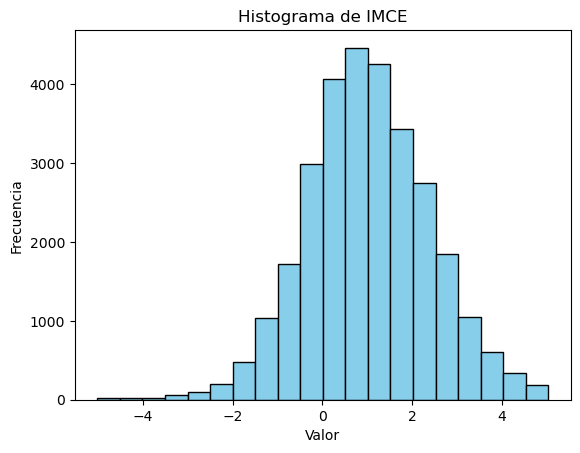

In [6]:
plt.hist(df['imce'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histograma de IMCE')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.show()

R: La data estaba bien, con pocos outliers o Nan por lo que solo se borraron esos Nan y se hizo un análisis a través de DataWrangler

## 2. EFA

In [7]:
df_sk = df[['sk1', 'sk2', 'sk3', 'sk4', 'sk5', 'sk6', 'sk7', 'sk8', 'sk9', 'sk10', 'sk11', 'sk12', 'sk13']]
fa = FactorAnalyzer(rotation='varimax').fit(df_sk)

In [8]:
np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format})
fa.loadings_

array([[0.170956, 0.541000, 0.150807],
       [0.173792, 0.512760, 0.354520],
       [0.179809, 0.587227, 0.162152],
       [0.195005, 0.685408, 0.194815],
       [0.121379, 0.214461, 0.716558],
       [0.163073, 0.203981, 0.486387],
       [0.070645, 0.074728, 0.146490],
       [0.269462, 0.097361, 0.478533],
       [0.496403, 0.205356, 0.201783],
       [0.555717, 0.120762, 0.127795],
       [0.665475, 0.206294, 0.202347],
       [0.524699, 0.109824, 0.141209],
       [0.480038, 0.150919, 0.132026]])

In [9]:
fa.get_eigenvalues()

(array([4.034214, 1.352109, 1.114244, 1.000843, 0.791244, 0.706343,
        0.701189, 0.690190, 0.608368, 0.529874, 0.517230, 0.491686,
        0.462466]),
 array([3.438924, 0.747141, 0.522044, 0.216095, 0.117614, 0.062805,
        0.007217, -0.011140, -0.034171, -0.063444, -0.081942, -0.084678,
        -0.128355]))

In [10]:
fa.get_communalities()

array([0.344650, 0.418811, 0.403460, 0.545763, 0.574182, 0.304773,
       0.032034, 0.311083, 0.329303, 0.339736, 0.526358, 0.307311,
       0.270644])

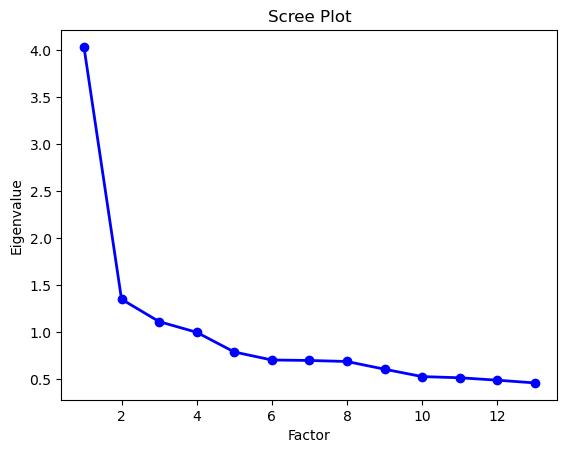

In [11]:
values = np.arange(1,14)
eigenvalues = pd.DataFrame(data=fa.get_eigenvalues())
plt.plot(values, eigenvalues.loc[0], 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Factor')
plt.ylabel('Eigenvalue')
plt.show()

In [12]:
fa.get_factor_variance()

(array([1.752553, 1.607039, 1.348517]),
 array([0.134812, 0.123618, 0.103732]),
 array([0.134812, 0.258430, 0.362162]))

In [13]:
print(semopy.efa.explore_cfa_model(df_sk, pval=0.01))

eta1 =~ sk11 + sk9 + sk10 + sk12 + sk13 + sk4
eta2 =~ sk7 + sk6
eta3 =~ sk4 + sk11 + sk2 + sk5 + sk3 + sk9 + sk1 + sk8 + sk6 + sk13



R: De este análisis, se puede observar claramente que la variable 'SK7' no es parte de ningún factor y no es explicado bien por ningún factor como se muestra en las comunalidades (3%), por lo que no se considerará para el modelo confirmatorio. Además, se puede ver por el método del codo que 3 Factores es lo correcto en este análisis, agregando que sus EigenValues son mayores que 1. 

Por otro lado, el modelo exploratorio que entrega Semopy no es el mejor, ya que considera que las variables pueden estar en más de un factor y no muestra buenos factores (a mi criterio).

Además, podemos agregar que la varianza explicada de las variables en los factores ronda entre los 30%-58% (Según las comunalidades).

## 3. Diferencias del Modelo con Variables 

In [14]:
fa = FactorAnalyzer(n_factors=3, rotation='varimax')
fa.fit(df_sk)

factor_scores = fa.transform(df_sk)

df_factors = pd.DataFrame(factor_scores, columns=['Factor1', 'Factor2', 'Factor3'])
df_factors = pd.concat([df_factors, df[['sexo', 'area', 'imce', 'act_fisica']].reset_index(drop=True)], axis=1)

In [15]:
df_factors.head(5)

,Factor1,Factor2,Factor3,sexo,area,imce,act_fisica
0,-0.711178,-0.311964,-0.400967,0,0,0.71,5.0
1,-0.708049,-0.316938,-0.484848,1,1,2.05,2.0
2,-0.709614,-0.314451,-0.442907,0,1,1.05,1.0
3,-0.787520,0.017855,-0.246423,0,0,1.39,4.0
4,1.759600,-0.071503,0.817094,1,1,2.75,2.0


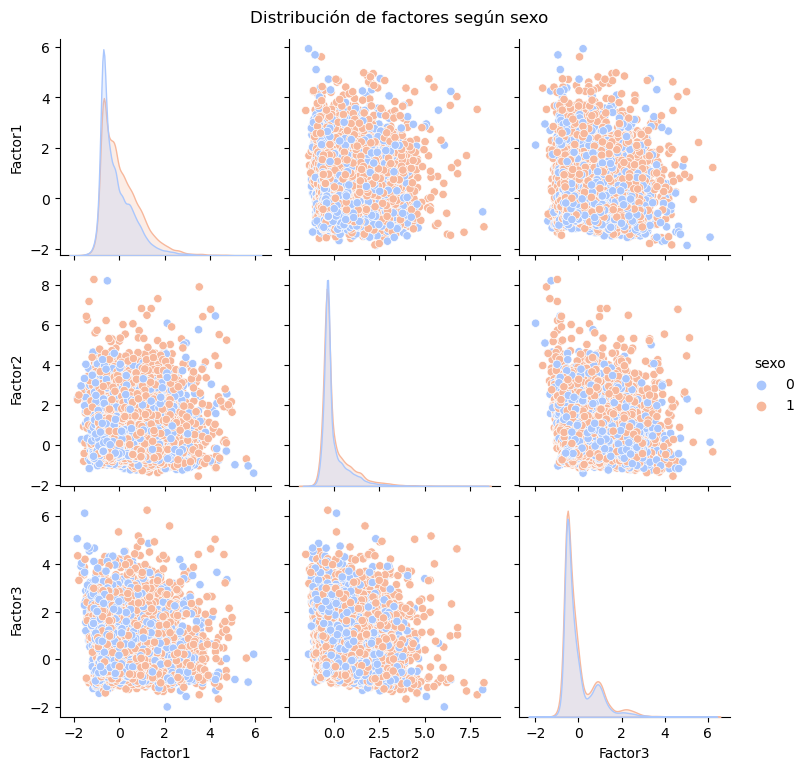

In [16]:
sns.pairplot(df_factors, vars=['Factor1', 'Factor2', 'Factor3'], hue='sexo', palette='coolwarm')
plt.suptitle("Distribución de factores según sexo", y=1.02)
plt.show()

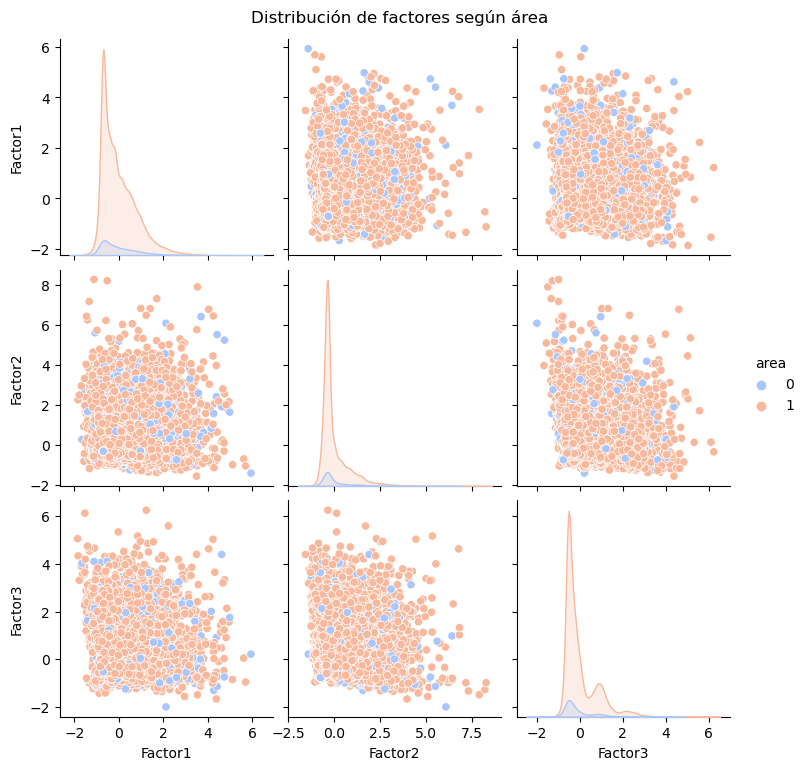

In [17]:
sns.pairplot(df_factors, vars=['Factor1', 'Factor2', 'Factor3'], hue='area', palette='coolwarm')
plt.suptitle("Distribución de factores según área", y=1.02)
plt.show()

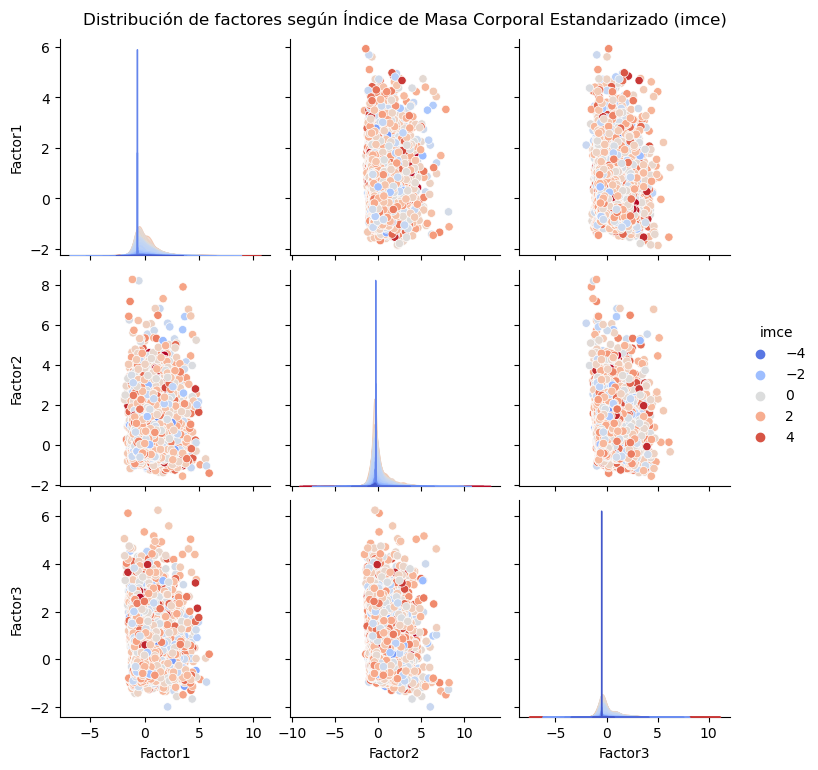

In [18]:
sns.pairplot(df_factors, vars=['Factor1', 'Factor2', 'Factor3'], hue='imce', palette='coolwarm')
plt.suptitle("Distribución de factores según Índice de Masa Corporal Estandarizado (imce)", y=1.02)
plt.show()

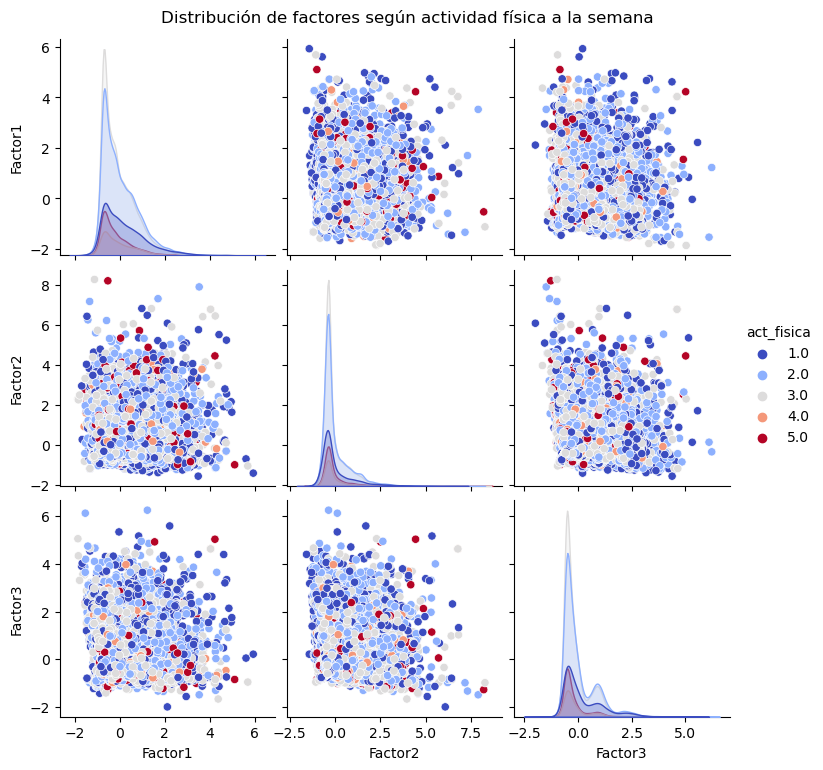

In [19]:
sns.pairplot(df_factors, vars=['Factor1', 'Factor2', 'Factor3'], hue='act_fisica', palette='coolwarm')
plt.suptitle("Distribución de factores según actividad física a la semana", y=1.02)
plt.show()

R: Según lo visto en los gráficos, podemos decir que no existe una separación clara de las variables en los factores, por lo que se ven dispersas los valores de las variables en todos los factores. Lo anterior, puede deberse a que las variables analizadas no fueron parte del análisis factorial, por lo que el Análisis no considero ningún tipo de separación con estas variables.

## 4. CFA

In [20]:
mod = """
Curiosidad =~ sk9 + sk10 + sk11 + sk12 + sk13
Afectividad =~ sk1 + sk2 + sk3 + sk4
Sociabilidad =~ sk5 + sk6 + sk8
"""

model = semopy.Model(mod)
out=model.fit(df_sk)
print(out)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.143
Number of iterations: 41
Params: 1.347 1.246 1.098 1.272 1.876 1.645 1.844 1.021 1.159 0.049 0.152 0.051 0.091 0.160 0.057 0.095 0.596 0.200 0.442 0.714 0.242 0.199 0.158 0.151 0.372 0.470 0.277


In [21]:
model.inspect(mode='list', what="names", std_est=True)

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk9,~,Curiosidad,1.000000,0.594873,-,-,-
1,sk10,~,Curiosidad,1.346839,0.562305,0.01854,72.644149,0.0
2,sk11,~,Curiosidad,1.245772,0.735504,0.014724,84.606271,0.0
3,sk12,~,Curiosidad,1.097571,0.541108,0.015529,70.676835,0.0
4,sk13,~,Curiosidad,1.271792,0.505956,0.018913,67.243421,0.0
5,sk1,~,Afectividad,1.000000,0.583084,-,-,-
6,sk2,~,Afectividad,1.876071,0.644674,0.023794,78.846648,0.0
7,sk3,~,Afectividad,1.645058,0.631947,0.021115,77.909473,0.0
8,sk4,~,Afectividad,1.843514,0.715743,0.022152,83.220784,0.0
9,sk5,~,Sociabilidad,1.000000,0.717647,-,-,-


In [22]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,51,66,4230.150078,0.0,80730.577968,0.948191,0.947602,0.93219,0.947602,0.932953,0.052585,53.714517,277.725724,0.142742


R: Según la relación y la carga que tienen las distintas variables en los factores, se hizo el modelo confirmatorio, obteniendo la siguiente estructura:

    Curiosidad = sk9 + sk10 + sk11 + sk12 + sk13
    Afectividad = sk1 + sk2 + sk3 + sk4
    Sociabilidad = sk5 + sk6 + sk8

Con esto podemos ver que las estimaciones para cada variable en el factor son significativas (p-value<0.5) y que, el modelo se ajusta bien a los datos y los factores están bien definidos según los estadísticos,

    TLI = 0.933
    RMSEA = 0.053
    CFI = 0.9482

Lo que indica que las relaciones entre variables y factor parecen apropiadas.

## 5. Clase Latente

In [23]:
df1=df[['imce']]

results = []
for n in range(1, 7):  # probar de 1 a 6 componentes
    model = StepMix(n_components=n, measurement="gaussian", verbose=0, random_state=123).fit(df1)
    bic = model.bic(df1)
    aic = model.aic(df1)
    ll = model.score(df1)
    entropy = model.relative_entropy(df1)
    results.append({'n_components': n, 'BIC': bic, 'AIC': aic, 'LogLikelihood': ll, 'Relative Entropy': entropy})

df_results = pd.DataFrame(results)
print(df_results)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00, 33.20it/s, max_LL=-5.5e+4, max_avg_LL=-1.86]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:01<00:00,  1.32s/it, max_LL=-5.17e+4, max_avg_LL=-1.74]


Fitting StepMix...


...

Initializations (n_init) : 100%|██████████| 1/1 [00:15<00:00, 15.45s/it, max_LL=-5.12e+4, max_avg_LL=-1.73]
/Users/antonio/anaconda3/envs/nuevo_entorno/lib/python3.11/site-packages/stepmix/stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:15<00:00, 15.02s/it, max_LL=-5.12e+4, max_avg_LL=-1.73]

   n_components            BIC            AIC  LogLikelihood  Relative Entropy
0             1  110050.091266  110041.794554      -1.856585               NaN
1             2  103429.704867  103404.814733      -1.744539          0.430243
2             3  102567.089024  102525.605467      -1.729637          0.647764
3             4  102531.108601  102473.031622      -1.728683          0.459772
4             5  102549.480147  102474.809745      -1.728645          0.325472
5             6  102569.213255  102477.949430      -1.728631          0.255846



/Users/antonio/anaconda3/envs/nuevo_entorno/lib/python3.11/site-packages/stepmix/stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


In [24]:
model = StepMix(n_components=3, measurement="gaussian", verbose=1, random_state=123)

# Fit model and predict clusters
model.fit(df1)
df['pred']=model.predict(df1)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:03<00:00,  3.45s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit               
          class_no                   0      1       2
          param variable                             
          means imce            0.5993  2.407 -1.9462
    Class weights
        Class 1 : 0.71
        Class 2 : 0.27
        Class 3 : 0.02
    Fit for 3 latent classes
    Estimation method             : 1-step
    Number of observations        : 29635
    Number of latent classes      : 3
    Number of estimated parameters: 5
    Log-likelihood (LL)           : -51257.8027
    -2LL                          : 102515.6055
    Average LL                    : -1.7296
    AIC                           : 102525.61
    BIC                           : 102567.09
    CAIC                          : 102572.09
    Sample-Size Adjusted BIC      : 102602.68
    Entropy                       : 11467.8729
    Scaled Relative Entropy       : 0.6478


In [25]:
print(df['pred'].describe())

count    29635.000000
mean         0.252674
std          0.465593
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          2.000000
Name: pred, dtype: float64


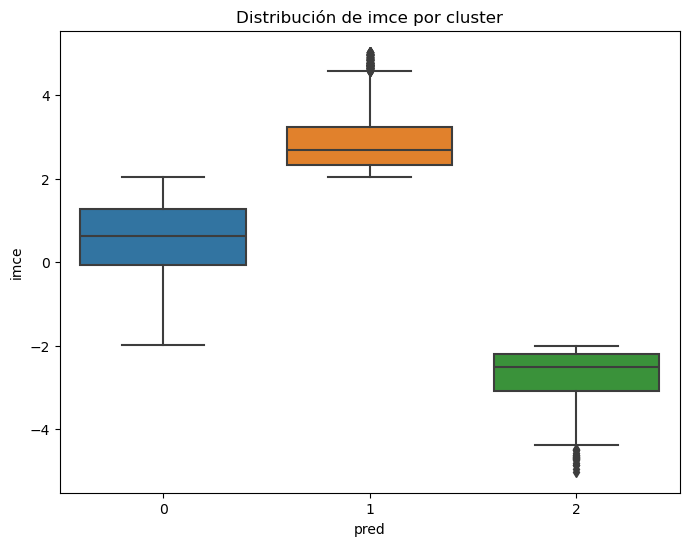

Las medias de los clusters son,
pred
0    0.541010
1    2.865563
2   -2.745749
Name: imce, dtype: float64


In [26]:
plt.figure(figsize=(8,6))
sns.boxplot(x='pred', y='imce', data=df)
plt.title('Distribución de imce por cluster')
plt.show()

cluster_means = df.groupby('pred')['imce'].mean()
print(f'Las medias de los clusters son,\n{cluster_means}')

R: Para analizar cuantas clases son buenas, se hizo una comparación entre números de clases de 1 al 6, teniendo mejor resultado con 3 clases, donde el BIC y la Entropía Relativa tenían buenos valores en conjunto respecto a los otros escenarios.

Con esto, se aplicó el método de clases latentes, resultando 3 clases marcadas y definiéndolas como:
    
    1. Clase 1 : Estándar o Promedio
    2. Clase 2 : Sobrepeso
    3. Clase 3 : Desnutrición

Además se hizo una predicción y se ve claramente en el gráfico de Caja (BoxPlot) como se distribuye el IMCE por cada cluster.


## 6. Modelo SEM

In [27]:
df = pd.get_dummies(df, columns=['act_fisica', 'madre_work'], drop_first=True, dtype=int)

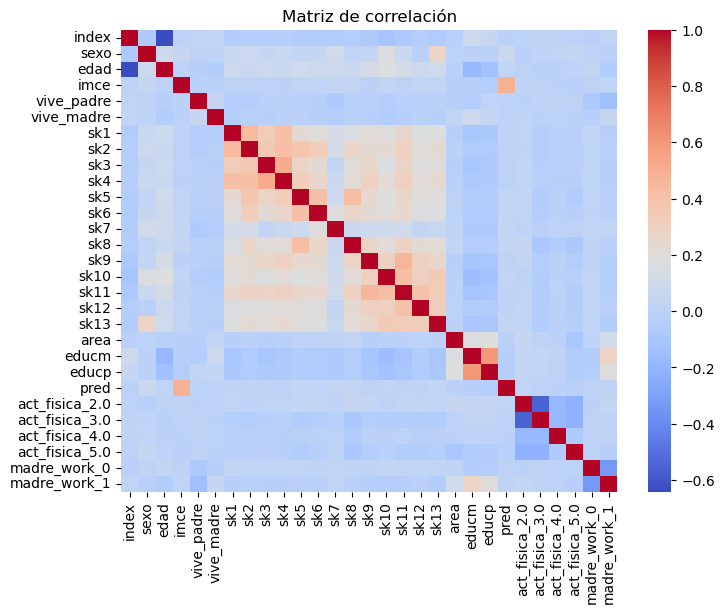

In [28]:
cor_matrix = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(cor_matrix, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación")
plt.show()


In [29]:
mod = """
# Measurement
Curiosidad =~ sk9 + sk10 + sk11 + sk12 + sk13
Afectividad =~ sk1 + sk2 + sk3 + sk4
Sociabilidad =~ sk5 + sk6 + sk8

#Structural
imce ~ Curiosidad + Afectividad + Sociabilidad + educm + educp + sexo + act_fisica_2.0 + act_fisica_3.0 + act_fisica_4.0 + act_fisica_5.0 + madre_work_0 + madre_work_1 + area + vive_madre + vive_padre
    """

model2 = semopy.Model(mod)
out=model2.fit(df)
print(out)
model2.inspect(mode='list', what="names", std_est=True)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.353
Number of iterations: 53
Params: 1.346 1.245 1.098 1.271 1.878 1.646 1.845 1.022 1.160 -0.050 -0.319 0.246 -0.005 -0.014 0.136 0.008 0.002 -0.089 -0.116 0.051 0.088 -0.140 -0.085 -0.013 0.049 0.152 0.051 0.091 0.160 0.057 1.858 0.095 0.596 0.200 0.442 0.714 0.242 0.199 0.158 0.151 0.372 0.469 0.277


,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk9,~,Curiosidad,1.000000,0.595084,-,-,-
1,sk10,~,Curiosidad,1.345665,0.562077,0.018525,72.640607,0.0
2,sk11,~,Curiosidad,1.245159,0.735459,0.014713,84.631766,0.0
3,sk12,~,Curiosidad,1.098075,0.541460,0.015526,70.726066,0.0
4,sk13,~,Curiosidad,1.270820,0.505779,0.0189,67.23933,0.0
5,sk1,~,Afectividad,1.000000,0.582865,-,-,-
6,sk2,~,Afectividad,1.877535,0.644849,0.023812,78.849563,0.0
7,sk3,~,Afectividad,1.645562,0.631885,0.021125,77.895373,0.0
8,sk4,~,Afectividad,1.844906,0.715942,0.022169,83.221171,0.0
9,sk5,~,Sociabilidad,1.000000,0.717456,-,-,-


In [30]:
semopy.calc_stats(model2)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,282,312,10467.635443,0.0,135090.518247,0.924427,0.922514,0.914271,0.922514,0.916387,0.034912,85.293563,442.052152,0.353219


R: Podemos ver que existen pocos valores estimados no significativos y que además, el modelo es aceptable considerando que,

    TLI = 0.9164
    RMSEA = 0.0349
    CFI = 0.9244

Además, se intentó hacer modelos estructurales donde se buscaba encontrar relaciones entre factores y otras variables, para ver si los factores eran explicados por otras variables pero no se logró nada bueno por lo que se decidió dejarlo simplemente lineal y con un modelo estructural.



## 7. Modelo por cada Cluster

### Cluster 1: Peso Estándar

In [31]:
df_cl1 = df[df['pred'] == 0]
df_cl2 = df[df['pred'] == 1]
df_cl3 = df[df['pred'] == 2]

In [32]:
mod = """
# Measurement
Curiosidad =~ sk9 + sk10 + sk11 + sk12 + sk13
Afectividad =~ sk1 + sk2 + sk3 + sk4
Sociabilidad =~ sk5 + sk6 + sk8

#Structural
imce ~ Curiosidad + Afectividad + Sociabilidad + educm + educp + sexo + act_fisica_2.0 + act_fisica_3.0 + act_fisica_4.0 + act_fisica_5.0 + madre_work_0 + madre_work_1 + area + vive_madre + vive_padre
    """

model_cl1 = semopy.Model(mod)
out=model_cl1.fit(df_cl1)
print(out)
model_cl1.inspect(mode='list', what="names", std_est=True)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.353
Number of iterations: 45
Params: 1.347 1.252 1.089 1.248 1.891 1.692 1.899 1.034 1.174 -0.026 -0.063 0.021 0.002 -0.009 -0.023 0.006 0.010 -0.046 -0.013 0.017 0.040 -0.061 -0.092 -0.006 0.047 0.149 0.050 0.088 0.153 0.055 0.823 0.095 0.586 0.196 0.435 0.704 0.241 0.194 0.158 0.147 0.365 0.451 0.278


,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk9,~,Curiosidad,1.000000,0.590859,-,-,-
1,sk10,~,Curiosidad,1.347160,0.562319,0.021355,63.083365,0.0
2,sk11,~,Curiosidad,1.251834,0.737497,0.017056,73.396283,0.0
3,sk12,~,Curiosidad,1.088565,0.537531,0.017817,61.096157,0.0
4,sk13,~,Curiosidad,1.248077,0.498218,0.02161,57.754375,0.0
5,sk1,~,Afectividad,1.000000,0.575790,-,-,-
6,sk2,~,Afectividad,1.890978,0.640734,0.027799,68.023684,0.0
7,sk3,~,Afectividad,1.692356,0.639494,0.024907,67.946127,0.0
8,sk4,~,Afectividad,1.899105,0.719530,0.026313,72.173458,0.0
9,sk5,~,Sociabilidad,1.000000,0.714426,-,-,-


In [33]:
semopy.calc_stats(model_cl1)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,282,312,7955.284347,0.0,103257.874336,0.925463,0.922957,0.914761,0.922957,0.917533,0.034729,85.294776,430.325831,0.352612


### Cluster 2: Sobrepeso

In [34]:
mod = """
# Measurement
Curiosidad =~ sk9 + sk10 + sk11 + sk12 + sk13
Afectividad =~ sk1 + sk2 + sk3 + sk4
Sociabilidad =~ sk5 + sk6 + sk8

#Structural
imce ~ Curiosidad + Afectividad + Sociabilidad + educm + educp + sexo + act_fisica_2.0 + act_fisica_3.0 + act_fisica_4.0 + act_fisica_5.0 + madre_work_0 + madre_work_1 + area + vive_madre + vive_padre
    """

model_cl2 = semopy.Model(mod)
out=model_cl2.fit(df_cl2)
print(out)
model_cl2.inspect(mode='list', what="names", std_est=True)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.393
Number of iterations: 42
Params: 1.353 1.234 1.142 1.347 1.805 1.479 1.642 0.981 1.107 -0.036 -0.169 0.158 -0.008 -0.004 0.179 -0.032 0.002 -0.069 -0.030 -0.004 -0.017 0.008 0.073 -0.011 0.057 0.158 0.054 0.100 0.186 0.065 0.443 0.096 0.626 0.211 0.468 0.742 0.245 0.215 0.159 0.165 0.397 0.524 0.272


,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk9,~,Curiosidad,1.000000,0.605464,-,-,-
1,sk10,~,Curiosidad,1.352749,0.561573,0.038821,34.845788,0.0
2,sk11,~,Curiosidad,1.234025,0.729829,0.030306,40.718775,0.0
3,sk12,~,Curiosidad,1.142368,0.552518,0.033173,34.43696,0.0
4,sk13,~,Curiosidad,1.347416,0.527563,0.040493,33.275416,0.0
5,sk1,~,Afectividad,1.000000,0.611815,-,-,-
6,sk2,~,Afectividad,1.804563,0.657697,0.046276,38.995369,0.0
7,sk3,~,Afectividad,1.478587,0.607239,0.039907,37.050408,0.0
8,sk4,~,Afectividad,1.642195,0.702171,0.040647,40.400966,0.0
9,sk5,~,Sociabilidad,1.000000,0.727136,-,-,-


In [35]:
semopy.calc_stats(model_cl2)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,282,312,2619.890536,0.0,30313.592702,0.922074,0.913574,0.904379,0.913574,0.913785,0.035284,85.213246,377.779861,0.393377


### Cluster 3: Desnutrición

In [36]:
mod = """
# Measurement
Curiosidad =~ sk9 + sk10 + sk11 + sk12 + sk13
Afectividad =~ sk1 + sk2 + sk3 + sk4
Sociabilidad =~ sk5 + sk6 + sk8

#Structural
imce ~ Curiosidad + Afectividad + Sociabilidad + educm + educp + sexo + act_fisica_2.0 + act_fisica_3.0 + act_fisica_4.0 + act_fisica_5.0 + madre_work_0 + madre_work_1 + area + vive_madre + vive_padre
    """

model_cl3 = semopy.Model(mod)
out=model_cl3.fit(df_cl3)
print(out)
model_cl3.inspect(mode='list', what="names", std_est=True)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.929
Number of iterations: 55
Params: 1.046 1.113 0.825 1.073 2.467 2.203 2.775 1.087 1.313 -0.046 1.027 -0.429 0.023 -0.004 -0.096 0.216 0.310 0.242 0.426 -0.065 0.024 0.162 0.403 -0.016 0.028 0.225 0.047 0.093 0.151 0.048 0.454 0.081 0.656 0.216 0.349 0.762 0.241 0.198 0.139 0.166 0.409 0.533 0.279


,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk9,~,Curiosidad,1.000000,0.667622,-,-,-
1,sk10,~,Curiosidad,1.046243,0.522097,0.119713,8.739616,0.0
2,sk11,~,Curiosidad,1.113308,0.750703,0.098941,11.252255,0.0
3,sk12,~,Curiosidad,0.825146,0.551732,0.090153,9.152704,0.0
4,sk13,~,Curiosidad,1.072854,0.503252,0.126669,8.46975,0.0
5,sk1,~,Afectividad,1.000000,0.505812,-,-,-
6,sk2,~,Afectividad,2.466740,0.642016,0.289199,8.529562,0.0
7,sk3,~,Afectividad,2.202539,0.636195,0.259422,8.490187,0.0
8,sk4,~,Afectividad,2.775424,0.779008,0.301314,9.211066,0.0
9,sk5,~,Sociabilidad,1.000000,0.691299,-,-,-


In [37]:
semopy.calc_stats(model_cl3)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,282,312,384.399098,0.000047,2225.52253,0.946487,0.827277,0.808902,0.827277,0.940794,0.029652,84.143,257.255236,0.9285


R: Se puede ver que la estimación de los parámetros cambia aplicando el modelo por clusters, esto debido a que hay algunas variables que pueden aportar de distinta manera según cada cluster, por ejemplo: 

    Lo explicado en el Cluster 2 de la variable Afectividad en el IMCE aporta de manera negativa, mientras que en el Cluster 3 la variable aporta de manera positiva, siendo en ambos modelos significativa.

Además, los modelos presentaron buenos resultados en los estadísticos por lo que podemos decir que es un buen ajuste, como se muestra a continuación,

    1. Cluster 1:
        TLI : 0.9175
        RMSEA : 0.0347
        CFI : 0.9255
    
    2. Cluster 2:
        TLI : 0.9138
        RMSEA : 0.0353
        CFI : 0.9221

    3. Cluster 3:
        TLI : 0.9408
        RMSEA : 0.0297
        CFI : 0.9465

FInalmente, si nosotros queremos ver una forma en general, es mucho mejor aplicar el modelo a DF original, con todos los clusters, pero si se quiere ver de forma más profunda, es bueno aplicar el modelo para cada Cluster ya que nos permite ver como afectan ciertos factores o variables a cada Cluster en específico y como pueden caracterizar cada cluster, por lo que agrega más valor al análisis.  
    